# <span style="color: rgba(230, 0, 126, 1);"> DESAFÍO 1 </span> #

## <span style="color: rgba(230, 0, 126, 1);"> Analistas de Finanzas y Riesgo Creditício </span> ##

### <span style="color: rgba(230, 0, 126, 1);"> 1.- Enunciado </span> ###
- En qué medida los clientes con saldos más bajos están en más riesgo de incumplimiento de crédito?
- Como tenemos que ajustar nuestras políticas de crédito para mitigar este riesgo?

### <span style="color: rgba(230, 0, 126, 1);"> Importación de librerias para el análisis de datos </span> ###

In [ ]:
# importación de librerias para el análisis de datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### <span style="color: rgba(230, 0, 126, 1);"> Carga de datos desde archivo CSV original </span> ###

In [ ]:
# la r al inicio cambia el sentido de la contrabarra en el path del repositorio local copiada directamente del explorador de windows. sep0";" indica como están separados los campos en el archivo csv"
df=pd.read_csv(r"C:\MNG\03_IT Academy\04_Simulador empresarial (SE)\251027_MNG_W01\251027_tabla BANK_marketing(original).csv",sep=";")
df.describe()

In [2]:
from sqlalchemy import create_engine

username = 'Equipo18'
password = 'E1q2u3i4p5o18'
host = '212.227.90.6'
database = 'Equip_18'

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")

In [3]:
from sqlalchemy import inspect
inspector = inspect(engine)

tables = inspector.get_table_names()

for table in tables:
    df = pd.read_sql(f"SELECT * FROM {table}", engine)
    globals()[f'df_{table}'] = df  
    

### <span style="color: rgba(230, 0, 126, 1);"> EDA </span> ###

In [4]:
df['default'].value_counts()

default
no     10994
yes      168
Name: count, dtype: int64

In [5]:
df['balance'].describe()

count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64

C:\Users\mange\AppData\Local\Temp\ipykernel_10920\1847034575.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='balance', data=df,palette="Set2")


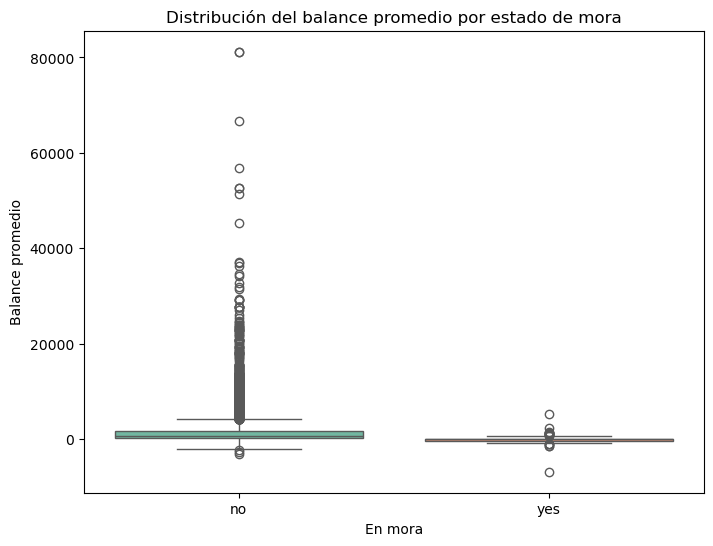

In [6]:
plt.figure(figsize=(8,6))
sns.boxplot(x='default', y='balance', data=df,palette="Set2")
plt.title("Distribución del balance promedio por estado de mora")
plt.xlabel("En mora")
plt.ylabel("Balance promedio")
plt.show();


### <span style="color: rgba(230, 0, 126, 1);"> Correlación </span> ###

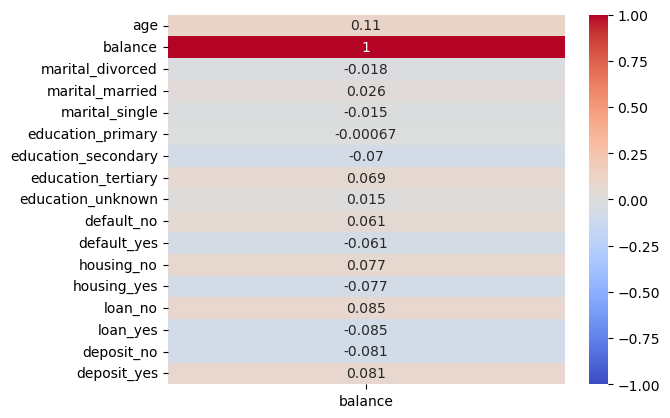

In [7]:
sns.heatmap(pd.get_dummies(df.drop(columns = ["id","contact","job","day","month", "duration","campaign","pdays","previous","poutcome"])).corr()[["balance"]],
            annot=True,           # esto me ayuda a mostrar los coeficientes
            cmap='coolwarm',      # paleta de colores
            vmin=-1, vmax=1);      # aca defino la escala de correlacion

### <span style="color: rgba(230, 0, 126, 1);"> Calculo de tasas </span> ###

In [8]:
neg = df[(df['balance'] < 0) & (df['default'] == 'yes')].shape[0]
no_neg = df[(df['balance'] >= 0) & (df['default'] == 'yes')].shape[0]
total_neg = df[df['balance'] < 0].shape[0]
total_no_neg = df[(df['balance'] >= 0) ].shape[0]

tasa_neg = neg / total_neg * 100
tasa_no_neg = no_neg / total_no_neg * 100




print(f"Número total de clientes con balance negativo: {total_neg:.2f}")
print(f"Número de clientes con balance negativo y mora: {neg:.2f}")
print()
print(f"Número total de clientes con balance positivo: {total_no_neg:.2f}")
print(f"Número de clientes con balance positivo y mora: {no_neg:.2f}")
print()
print(f"Tasa de mora con saldo negativo: {tasa_neg:.2f}%")
print(f"Tasa de mora con saldo positivo: {tasa_no_neg:.2f}%")


Número total de clientes con balance negativo: 688.00
Número de clientes con balance negativo y mora: 78.00

Número total de clientes con balance positivo: 10474.00
Número de clientes con balance positivo y mora: 90.00

Tasa de mora con saldo negativo: 11.34%
Tasa de mora con saldo positivo: 0.86%


### <span style="color: rgba(230, 0, 126, 1);"> Definición rangos </span> ###

In [9]:

# Definir los límites de los rangos
bins = [-float('inf'), -0.000001, 500, 2000, 10000]
labels = ['Negativo', 'Bajo', 'Medio', 'Alto']

# Crear la columna categórica
df['rango_balance'] = pd.cut(df['balance'], bins=bins, labels=labels)

# Verificar cuántos clientes hay en cada categoría
print(df['rango_balance'].value_counts())


rango_balance
Bajo        4661
Medio       3371
Alto        2214
Negativo     688
Name: count, dtype: int64


### <span style="color: rgba(230, 0, 126, 1);"> Calculo tasas por rango</span> ###

In [10]:
tasa_mora = pd.crosstab(df['rango_balance'], df['default'], normalize='index') * 100
print(tasa_mora)


default               no        yes
rango_balance                      
Negativo       88.662791  11.337209
Bajo           98.369449   1.630551
Medio          99.644023   0.355977
Alto           99.909666   0.090334


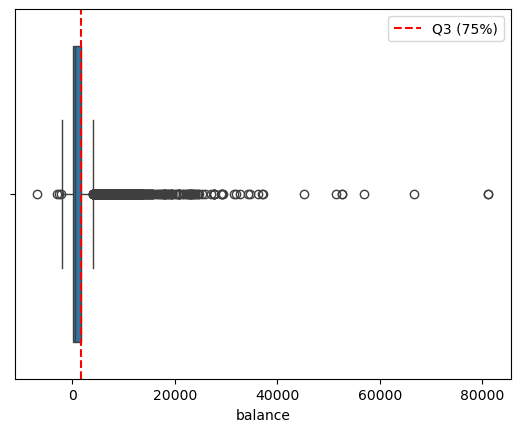

In [11]:

sns.boxplot(x=df['balance'])
plt.axvline(df['balance'].quantile(0.75), color='red', linestyle='--', label='Q3 (75%)')
plt.legend()
plt.show()


In [ ]:
# Calculo las 4 medidas estadísticas básicas a partir del balance

media=df["balance"].mean()
mediana=df["balance"].median()
percentil_25=np.percentile(df["balance"],25)
percentil_75=np.percentile(df["balance"],75)

# Gráfica en la que se muestran el histográma que representa a la variable numérica "amount"
df["balance"].plot.hist(bins=50,edgecolor="white",label="balance")

# Lineas auxilliares sobre el gráfico
plt.axvline(media, color='black', linestyle='dashed', linewidth=1, label=f'media: {media:.2f}')
plt.axvline(percentil_25, color='red', linestyle='dashed', linewidth=1, label=f'percentil_25: {percentil_25:.2f}')
plt.axvline(percentil_75, color='green', linestyle='dashed', linewidth=1, label=f'percentil_75: {percentil_75:.2f}')

# Configuración de las etiquetas de los ejes y de la leyenda
plt.title("HISTOGRAMA BALANCE")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel("Balance")
plt.ylabel("");

### <span style="color: rgba(230, 0, 126, 1);"> Categorizar los saldos: negativo- positivo </span> ###

In [ ]:
# definir los límites de los intervalos (bins)
# [-10000,2000) es bajo, [2000,10000) es medio y [10000,100000] es alto
intervalos=[-10000,0,100000]

# definir las etiquetas para cada intervalo
etiquetas=['negativo','positivo']

# creamos nueva columna con pd.cut()
df['balance_range']=pd.cut(df['balance'],bins=intervalos,labels=etiquetas,right=False)

# mover la nueva columna junto 'balance'
col = 'balance_range'
col_ref = 'balance'  # columna de referencia

cols = list(df.columns)
cols.insert(cols.index(col_ref) + 1, cols.pop(cols.index(col)))
df = df[cols]

df

In [ ]:
# calcular la media de balance
media_balance=df['balance'].mean().round(2)
print(f'La media de BALANCE es:',media_balance)

In [ ]:
# filtrar balances
df_balanceNegativo=df.loc[df['balance']<0].shape
print(f'registros con balance negativo:',df_balanceNegativo)
df_balanceCero=df.loc[df['balance']==0].shape
print(f'registros con balance 0:',df_balanceCero)
df_balancePositivo=df.loc[df['balance']>0].shape
print(f'registros con balance positivo:',df_balancePositivo)

In [ ]:
# Busco si hay relación entre el balance y la edad de los clientes
sns.lmplot(data=df,x="balance",y="age")

In [ ]:
# distribución percentil (boxplot)

# Estilo visual de Seaborn
sns.set_context("notebook")     # Texto más grande (ideal para presentaciones)

# Crear figura más amplia y alta
plt.figure(figsize=(10, 8))

# Boxplot
sns.boxplot(
    data=df,
    x="default",
    y="balance",
    hue="balance_range",
    palette="Set1",  # Paleta de colores más amable
    width=0.5,       # Ancho de las cajas (un poco más delgado para claridad)
    fliersize=1      # Tamaño de los puntos outliers
)

# Títulos y etiquetas
plt.title("Distribución de balance según default y saldo", fontsize=10, weight='bold', pad=15)
plt.xlabel("Default", fontsize=10)
plt.ylabel("Balance", fontsize=10)

# Limitar eje Y si lo deseas
plt.ylim(-3000, 4500)

# Leyenda a la derecha, sin sobreponer el gráfico
plt.legend(
    title="Saldo",
    bbox_to_anchor=(1.02, 0.8),
    loc="upper left",
)

# Ajuste de márgenes
plt.tight_layout()

plt.show()
